# 3. Рекуррентные нейросети

## 1. Используемые библиотеки

In [ ]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr



## 2. Загрузка и просмотр датасета


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Bike_sharing/hour.csv', sep=',')

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('\n--- Первые 5 строк ---')
display(df.head())

print('\n--- Типы данных и наличие значений ---')
print(df.info())

Размер датасета: 17379 строк, 17 столбцов

--- Первые 5 строк ---


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1



--- Типы данных и наличие значений ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


## 3. Подготовка датасета

*   Очистка не требуется, так как в датасете нет пропусков или дубликатов
*   Определяем целевую переменную и признаки для модели

In [ ]:
# Целевая переменная
target = 'cnt'

# Признаки для модели (убираем instant, dteday, casual, registered)
features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
            'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

df_model = df[features + [target]].copy()

## 4. Циклически кодируем время

In [ ]:
def encode_cyclical(df, column, max_val):
    """Кодируем циклический признак через sin/cos"""
    df[f'{column}_sin'] = np.sin(2 * np.pi * df[column] / max_val)
    df[f'{column}_cos'] = np.cos(2 * np.pi * df[column] / max_val)
    return df

# Применяем к временным признакам
df_model = encode_cyclical(df_model, 'hr', 24)
df_model = encode_cyclical(df_model, 'mnth', 12)
df_model = encode_cyclical(df_model, 'weekday', 7)

# Удаляем исходные циклические столбцы
df_model = df_model.drop(columns=['hr', 'mnth', 'weekday'])

## 5. Нормализация данных

RNN чувствительны к масштабу — нормализуем всё в диапазон [0, 1]

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_model)

# Сохраняем индексы для обратного преобразования прогнозов
target_idx = list(df_model.columns).index(target)

## Создание последовательностей (time steps)

In [ ]:
def create_sequences(data, target_idx, time_steps=24):

    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

TIME_STEPS = 24  # Используем последние 24 часа для прогноза
X, y = create_sequences(scaled_data, target_idx, TIME_STEPS)

print(f"Форма X: {X.shape}")  # (samples, time_steps, features)
print(f"Форма y: {y.shape}")  # (samples,)

Форма X: (17355, 24, 16)
Форма y: (17355,)


## Разделение на обучающую и тестовую выборку

In [ ]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Train: 13884 samples, Test: 3471 samples


# RNN

## Ручная реализация RNN

In [ ]:
class SimpleRNN:
    def __init__(self, input_size, hidden_size=64, output_size=1,
                 learning_rate=0.01, epochs=100, clip_value=5.0, seed=42):

        np.random.seed(seed)
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lr = learning_rate
        self.epochs = epochs
        self.clip_value = clip_value

        scale_input = np.sqrt(2.0 / (input_size + hidden_size))
        scale_hidden = np.sqrt(2.0 / (hidden_size + hidden_size))

        self.Wxh = np.random.randn(input_size, hidden_size) * scale_input
        self.bh = np.zeros((1, hidden_size))
        self.Whh = np.random.randn(hidden_size, hidden_size) * scale_hidden
        self.Why = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / (hidden_size + output_size))
        self.by = np.zeros((1, output_size))

        self.loss_history = []
        self.val_loss_history = []

    def _tanh(self, x):
        return np.tanh(x)

    def _tanh_derivative(self, x):
        return 1 - np.tanh(x) ** 2

    def forward(self, X):
        batch_size, time_steps, _ = X.shape
        h = np.zeros((batch_size, self.hidden_size))

        cache = {
            'X': X,
            'h': [h.copy()],
            'z': []
        }

        for t in range(time_steps):
            x_t = X[:, t, :]
            z_t = x_t @ self.Wxh + h @ self.Whh + self.bh
            h = self._tanh(z_t)

            cache['h'].append(h.copy())
            cache['z'].append(z_t)

        y_pred = h @ self.Why + self.by

        cache['h_final'] = h
        cache['y_pred'] = y_pred

        return y_pred, cache

    def backward(self, y_true, y_pred, cache):
        X = cache['X']
        batch_size, time_steps, _ = X.shape

        gradients = {
            'dWxh': np.zeros_like(self.Wxh),
            'dWhh': np.zeros_like(self.Whh),
            'dbh': np.zeros_like(self.bh),
            'dWhy': np.zeros_like(self.Why),
            'dby': np.zeros_like(self.by)
        }

        # Градиент MSE loss
        dy = (y_pred - y_true) * 2 / batch_size

        h_final = cache['h_final']
        gradients['dWhy'] = h_final.T @ dy
        gradients['dby'] = np.sum(dy, axis=0, keepdims=True)

        dh_next = dy @ self.Why.T

        # BPTT с ограничением по времени (truncated BPTT)
        for t in reversed(range(time_steps)):
            x_t = X[:, t, :]
            h_t = cache['h'][t + 1]
            h_prev = cache['h'][t]
            z_t = cache['z'][t]

            dz = dh_next * self._tanh_derivative(z_t)

            gradients['dWxh'] += x_t.T @ dz
            gradients['dWhh'] += h_prev.T @ dz
            gradients['dbh'] += np.sum(dz, axis=0, keepdims=True)

            dh_next = dz @ self.Whh.T

            # Ограничиваем обратное распространение
            if np.linalg.norm(dh_next) < 1e-7:
                break

        return gradients

    def clip_gradients(self, gradients):
        total_norm = 0
        for key in gradients:
            total_norm += np.sum(gradients[key] ** 2)
        total_norm = np.sqrt(total_norm)

        if total_norm > self.clip_value:
            for key in gradients:
                gradients[key] = gradients[key] * self.clip_value / total_norm

        return gradients

    def update_weights(self, gradients):
        if not hasattr(self, 'velocity'):
            self.velocity = {key: np.zeros_like(grad) for key, grad in gradients.items()}

        momentum = 0.9
        for key in gradients:
            self.velocity[key] = momentum * self.velocity[key] - self.lr * gradients[key]

        self.Wxh += self.velocity['dWxh']
        self.Whh += self.velocity['dWhh']
        self.bh += self.velocity['dbh']
        self.Why += self.velocity['dWhy']
        self.by += self.velocity['dby']

    def compute_loss(self, y_true, y_pred):
        return np.mean((y_pred - y_true) ** 2)

    def fit(self, X_train, y_train, X_val=None, y_val=None, batch_size=32, verbose=True):
        n_samples = X_train.shape[0]
        y_train = y_train.reshape(-1, self.output_size)

        for epoch in range(self.epochs):
            # Перемешиваем данные
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            epoch_loss = 0
            n_batches = 0

            # Mini-batch обучение
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                if len(X_batch) == 0:
                    continue

                # Forward
                y_pred, cache = self.forward(X_batch)

                # Loss
                batch_loss = self.compute_loss(y_batch, y_pred)
                epoch_loss += batch_loss
                n_batches += 1

                # Backward
                gradients = self.backward(y_batch, y_pred, cache)
                gradients = self.clip_gradients(gradients)

                # Update
                self.update_weights(gradients)

            train_loss = epoch_loss / n_batches

            # Валидация
            val_loss = None
            if X_val is not None and y_val is not None:
                y_val_pred, _ = self.forward(X_val)
                val_loss = self.compute_loss(y_val.reshape(-1, self.output_size), y_val_pred)

            self.loss_history.append(train_loss)
            if val_loss is not None:
                self.val_loss_history.append(val_loss)

            if verbose and (epoch + 1) % 10 == 0:
                if val_loss is not None:
                    print(f"Epoch {epoch+1}/{self.epochs} - "
                          f"Train Loss: {train_loss:.6f} - "
                          f"Val Loss: {val_loss:.6f}")
                else:
                    print(f"Epoch {epoch+1}/{self.epochs} - Train Loss: {train_loss:.6f}")

        return self

    def predict(self, X):
        predictions, _ = self.forward(X)
        return predictions.flatten()

## Обучение ручной модели

In [ ]:
y_train_norm = y_train
y_test_norm = y_test

print(f"y_train диапазон: [{y_train_norm.min():.4f}, {y_train_norm.max():.4f}]")

# Создаем модель
rnn = SimpleRNN(
    input_size=X_train.shape[2],
    hidden_size=64,
    output_size=1,
    learning_rate=0.01,
    epochs=100,
    clip_value=5.0,
    seed=42
)

# 3. Обучаем с batch_size
rnn.fit(X_train, y_train_norm, X_val=X_test, y_val=y_test_norm,
        batch_size=64, verbose=True)

# 4. Предсказания
y_pred_train = rnn.predict(X_train)
y_pred_test = rnn.predict(X_test)

# 5. Обратное преобразование
n_features = scaled_data.shape[1]
y_train_inv, y_pred_train_inv = inverse_transform_target(
    y_train_norm, y_pred_train, scaler, target_idx, n_features
)
y_test_inv, y_pred_test_inv = inverse_transform_target(
    y_test_norm, y_pred_test, scaler, target_idx, n_features
)

# Ограничиваем предсказания (не может быть отрицательных аренд)
y_pred_train_inv = np.maximum(0, y_pred_train_inv)
y_pred_test_inv = np.maximum(0, y_pred_test_inv)



y_train диапазон: [0.0000, 0.9795]
Epoch 10/100 - Train Loss: 0.002619 - Val Loss: 0.005501
Epoch 20/100 - Train Loss: 0.001974 - Val Loss: 0.004112
Epoch 30/100 - Train Loss: 0.001667 - Val Loss: 0.003605
Epoch 40/100 - Train Loss: 0.001534 - Val Loss: 0.003402
Epoch 50/100 - Train Loss: 0.001434 - Val Loss: 0.003082
Epoch 60/100 - Train Loss: 0.001373 - Val Loss: 0.003073
Epoch 70/100 - Train Loss: 0.001328 - Val Loss: 0.002982
Epoch 80/100 - Train Loss: 0.001278 - Val Loss: 0.002917
Epoch 90/100 - Train Loss: 0.001268 - Val Loss: 0.002760
Epoch 100/100 - Train Loss: 0.001228 - Val Loss: 0.002796


## Оценка результатов


=== МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ ===
Метрика         Train                Test                
-------------------------------------------------------
MAE             22.58                33.32               
RMSE            33.78                51.45               
R² Score        0.9591               0.9456              

Корреляция Пирсона: 0.9741 (p=0.000000)


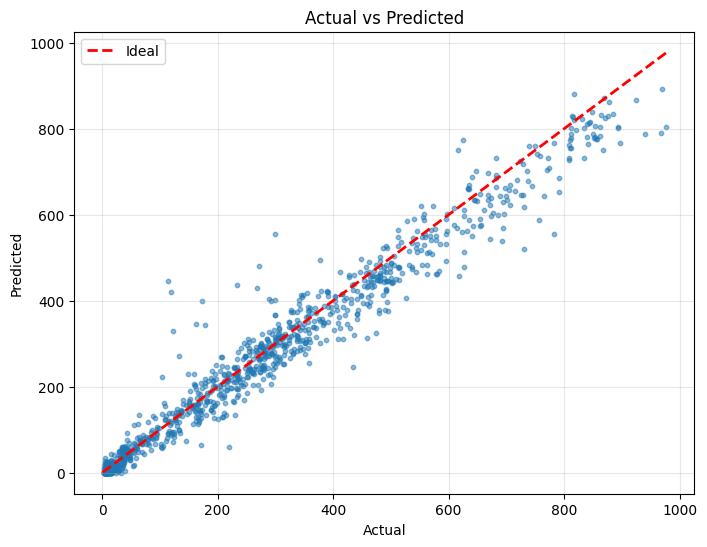

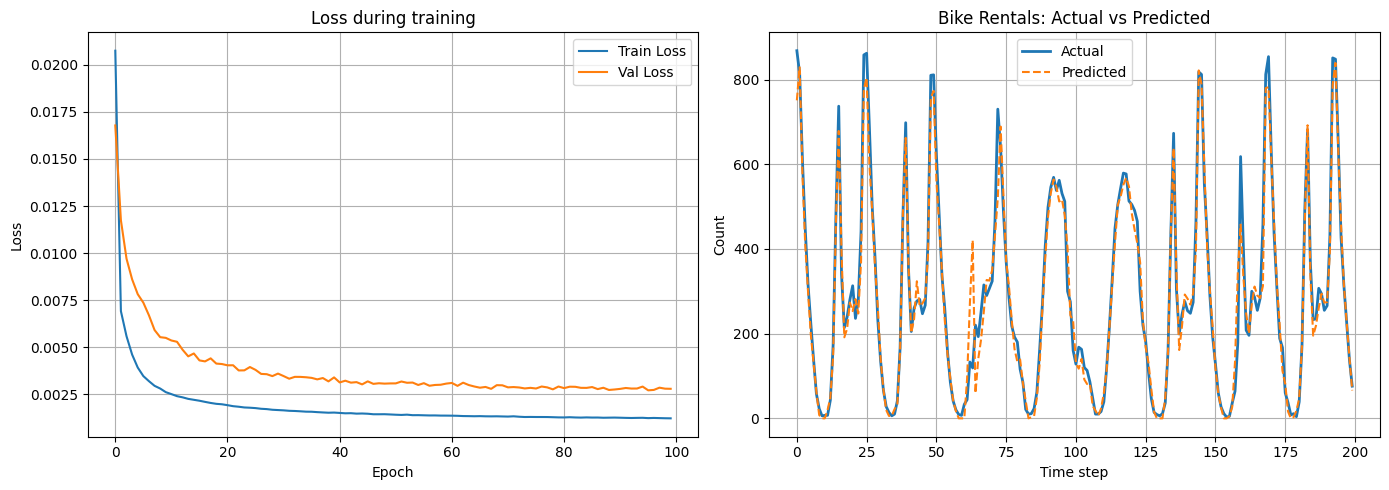


=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ===
Train Loss: 0.001228
Val Loss: 0.002796


In [ ]:
train_mae = mean_absolute_error(y_train_inv, y_pred_train_inv)
train_rmse = np.sqrt(mean_squared_error(y_train_inv, y_pred_train_inv))
train_r2 = r2_score(y_train_inv, y_pred_train_inv)

test_mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
test_rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_test_inv))
test_r2 = r2_score(y_test_inv, y_pred_test_inv)

print("\n=== МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ ===")
print(f"{'Метрика':<15} {'Train':<20} {'Test':<20}")
print("-" * 55)
print(f"{'MAE':<15} {train_mae:<20.2f} {test_mae:<20.2f}")
print(f"{'RMSE':<15} {train_rmse:<20.2f} {test_rmse:<20.2f}")
print(f"{'R² Score':<15} {train_r2:<20.4f} {test_r2:<20.4f}")

# Корреляция
corr, p_value = pearsonr(y_test_inv, y_pred_test_inv)
print(f"\nКорреляция Пирсона: {corr:.4f} (p={p_value:.6f})")

# 7. Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(y_test_inv[:1000], y_pred_test_inv[:1000], alpha=0.5, s=10)
plt.plot([y_test_inv.min(), y_test_inv.max()],
         [y_test_inv.min(), y_test_inv.max()],
         'r--', linewidth=2, label='Ideal')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# График потерь
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(rnn.loss_history, label='Train Loss')
if len(rnn.val_loss_history) > 0:
    plt.plot(rnn.val_loss_history, label='Val Loss')
plt.title('Loss during training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
sample_size = 200
plt.plot(y_test_inv[:sample_size], label='Actual', linewidth=2)
plt.plot(y_pred_test_inv[:sample_size], label='Predicted', linestyle='--')
plt.title('Bike Rentals: Actual vs Predicted')
plt.xlabel('Time step')
plt.ylabel('Count')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n=== ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ===")
print(f"Train Loss: {rnn.loss_history[-1]:.6f}")
if len(rnn.val_loss_history) > 0:
    print(f"Val Loss: {rnn.val_loss_history[-1]:.6f}")

# LSTM

## Ручная реализация

In [ ]:
class ManualLSTM:
    def __init__(self, input_dim, hidden_dim=64, lr=0.001):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.t = 0

        # Инициализация весов
        sc = np.sqrt(1.0 / hidden_dim)

        self.Wf = np.random.randn(input_dim, hidden_dim) * sc
        self.Uf = np.random.randn(hidden_dim, hidden_dim) * sc
        self.bf = np.ones(hidden_dim)

        self.Wi = np.random.randn(input_dim, hidden_dim) * sc
        self.Ui = np.random.randn(hidden_dim, hidden_dim) * sc
        self.bi = np.zeros(hidden_dim)

        self.Wg = np.random.randn(input_dim, hidden_dim) * sc
        self.Ug = np.random.randn(hidden_dim, hidden_dim) * sc
        self.bg = np.zeros(hidden_dim)

        self.Wo = np.random.randn(input_dim, hidden_dim) * sc
        self.Uo = np.random.randn(hidden_dim, hidden_dim) * sc
        self.bo = np.zeros(hidden_dim)

        self.Wout = np.random.randn(hidden_dim, 1) * sc
        self.bout = np.zeros(1)

        self._init_adam_moments()

    def _init_adam_moments(self):
        self.mWf, self.vWf = np.zeros_like(self.Wf), np.zeros_like(self.Wf)
        self.mUf, self.vUf = np.zeros_like(self.Uf), np.zeros_like(self.Uf)
        self.mbf, self.vbf = np.zeros_like(self.bf), np.zeros_like(self.bf)

        self.mWi, self.vWi = np.zeros_like(self.Wi), np.zeros_like(self.Wi)
        self.mUi, self.vUi = np.zeros_like(self.Ui), np.zeros_like(self.Ui)
        self.mbi, self.vbi = np.zeros_like(self.bi), np.zeros_like(self.bi)

        self.mWg, self.vWg = np.zeros_like(self.Wg), np.zeros_like(self.Wg)
        self.mUg, self.vUg = np.zeros_like(self.Ug), np.zeros_like(self.Ug)
        self.mbg, self.vbg = np.zeros_like(self.bg), np.zeros_like(self.bg)

        self.mWo, self.vWo = np.zeros_like(self.Wo), np.zeros_like(self.Wo)
        self.mUo, self.vUo = np.zeros_like(self.Uo), np.zeros_like(self.Uo)
        self.mbo, self.vbo = np.zeros_like(self.bo), np.zeros_like(self.bo)

        self.mWout, self.vWout = np.zeros_like(self.Wout), np.zeros_like(self.Wout)
        self.mbout, self.vbout = np.zeros_like(self.bout), np.zeros_like(self.bout)

    def _sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    def _tanh(self, x):
        return np.tanh(x)

    def forward(self, X):
        B, T, _ = X.shape

        # Инициализация состояний
        h = np.zeros((B, self.hidden_dim))
        c = np.zeros((B, self.hidden_dim))

        # Сохранение для backprop
        self._X = X
        self._hs = [h.copy()]
        self._cs = [c.copy()]
        self._fs, self._is, self._gs, self._os = [], [], [], []

        for t in range(T):
            x_t = X[:, t, :]

            # Forget gate
            f = self._sigmoid(x_t @ self.Wf + h @ self.Uf + self.bf)

            # Input gate
            i = self._sigmoid(x_t @ self.Wi + h @ self.Ui + self.bi)

            # Cell candidate
            g = self._tanh(x_t @ self.Wg + h @ self.Ug + self.bg)

            # Output gate
            o = self._sigmoid(x_t @ self.Wo + h @ self.Uo + self.bo)

            # Update cell state
            c = f * c + i * g

            # Update hidden state
            h = o * self._tanh(c)

            # Сохраняем для backprop
            self._hs.append(h.copy())
            self._cs.append(c.copy())
            self._fs.append(f)
            self._is.append(i)
            self._gs.append(g)
            self._os.append(o)

        # Output layer
        y_pred = h @ self.Wout + self.bout
        return y_pred

    def backward(self, y_true, y_pred):
        B, T, _ = self._X.shape

        # Градиент от функции потерь (MSE)
        dy = 2 * (y_pred - y_true.reshape(-1, 1)) / B

        # Градиенты выходного слоя
        dWout = self._hs[T].T @ dy
        dbout = np.sum(dy, axis=0)

        # Начальные градиенты для обратного прохода
        dh_next = dy @ self.Wout.T
        dc_next = np.zeros_like(dh_next)

        # Инициализация градиентов для всех весов
        grads = {name: np.zeros_like(getattr(self, name))
                 for name in ['Wf', 'Uf', 'bf', 'Wi', 'Ui', 'bi',
                             'Wg', 'Ug', 'bg', 'Wo', 'Uo', 'bo']}

        # BPTT
        for t in reversed(range(T)):
            x_t = self._X[:, t, :]
            h_prev = self._hs[t]
            c_prev = self._cs[t]
            c_curr = self._cs[t+1]

            f = self._fs[t]
            i = self._is[t]
            g = self._gs[t]
            o = self._os[t]

            tanh_c = self._tanh(c_curr)

            # Градиенты гейтов
            do = dh_next * tanh_c
            dc = dh_next * o * (1 - tanh_c**2) + dc_next

            df = dc * c_prev
            di = dc * g
            dg = dc * i
            dc_next = dc * f

            # Градиенты активаций
            do_raw = do * o * (1 - o)
            df_raw = df * f * (1 - f)
            di_raw = di * i * (1 - i)
            dg_raw = dg * (1 - g**2)

            # Градиенты весов
            grads['Wf'] += x_t.T @ df_raw
            grads['Uf'] += h_prev.T @ df_raw
            grads['bf'] += np.sum(df_raw, axis=0)

            grads['Wi'] += x_t.T @ di_raw
            grads['Ui'] += h_prev.T @ di_raw
            grads['bi'] += np.sum(di_raw, axis=0)

            grads['Wg'] += x_t.T @ dg_raw
            grads['Ug'] += h_prev.T @ dg_raw
            grads['bg'] += np.sum(dg_raw, axis=0)

            grads['Wo'] += x_t.T @ do_raw
            grads['Uo'] += h_prev.T @ do_raw
            grads['bo'] += np.sum(do_raw, axis=0)

            # Градиент для предыдущего hidden state
            dh_next = (df_raw @ self.Uf.T + di_raw @ self.Ui.T +
                      dg_raw @ self.Ug.T + do_raw @ self.Uo.T)

        # Обновление весов через Adam
        self._adam_update('Wout', dWout)
        self._adam_update('bout', dbout)

        for name in ['Wf', 'Uf', 'bf', 'Wi', 'Ui', 'bi',
                    'Wg', 'Ug', 'bg', 'Wo', 'Uo', 'bo']:
            self._adam_update(name, grads[name])

    def _adam_update(self, name, grad):
        param = getattr(self, name)
        grad = np.asarray(grad).reshape(param.shape)

        beta1, beta2, eps = 0.9, 0.999, 1e-8

        m_attr = f'm{name}'
        v_attr = f'v{name}'
        m = getattr(self, m_attr)
        v = getattr(self, v_attr)

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        self.t += 1
        m_hat = m / (1 - beta1 ** self.t)
        v_hat = v / (1 - beta2 ** self.t)

        param -= self.lr * m_hat / (np.sqrt(v_hat) + eps)

        setattr(self, m_attr, m)
        setattr(self, v_attr, v)

    def fit(self, X, y, epochs=50, batch_size=32):
        print("Обучение Manual LSTM")
        n = X.shape[0]

        for epoch in range(epochs):
            idx = np.random.permutation(n)
            X_shuf, y_shuf = X[idx], y[idx]
            epoch_loss = 0
            n_batches = 0

            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                X_b, y_b = X_shuf[start:end], y_shuf[start:end]

                y_pred = self.forward(X_b)
                loss = np.mean((y_pred - y_b.reshape(-1, 1))**2)
                epoch_loss += loss
                n_batches += 1

                self.backward(y_b, y_pred)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/n_batches:.4f}")

    def predict(self, X):
        y_pred = self.forward(X)
        return y_pred.flatten()

    def count_params(self):
        params = {
            'Forget gate (Wf + Uf + bf)': self.Wf.size + self.Uf.size + self.bf.size,
            'Input gate (Wi + Ui + bi)': self.Wi.size + self.Ui.size + self.bi.size,
            'Cell candidate (Wg + Ug + bg)': self.Wg.size + self.Ug.size + self.bg.size,
            'Output gate (Wo + Uo + bo)': self.Wo.size + self.Uo.size + self.bo.size,
            'Output layer (Wout + bout)': self.Wout.size + self.bout.size,
            'TOTAL': (self.Wf.size + self.Uf.size + self.bf.size +
                     self.Wi.size + self.Ui.size + self.bi.size +
                     self.Wg.size + self.Ug.size + self.bg.size +
                     self.Wo.size + self.Uo.size + self.bo.size +
                     self.Wout.size + self.bout.size)
        }
        return params

## Запуск ручной

In [ ]:
manual_lstm = ManualLSTM(input_dim=X_train.shape[2], hidden_dim=64, lr=0.001)
start_time = time.time()
manual_lstm.fit(X_train, y_train, epochs=50, batch_size=32)
manual_pred = manual_lstm.predict(X_test)
manual_metrics = evaluate_metrics(y_test, manual_pred)
print(f"Manual LSTM | MSE: {manual_metrics['MSE']:.2f} | RMSE: {manual_metrics['RMSE']:.2f} | MAE: {manual_metrics['MAE']:.2f}")
print(f"Время обучения Manual: {time.time() - start_time:.2f} сек")

Обучение Manual LSTM (NumPy)...
Epoch 10/50 | Loss: 0.0013
Epoch 20/50 | Loss: 0.0010
Epoch 30/50 | Loss: 0.0009
Epoch 40/50 | Loss: 0.0008
Epoch 50/50 | Loss: 0.0008
Manual LSTM | MSE: 0.00 | RMSE: 0.04 | MAE: 0.03
Время обучения Manual: 527.96 сек


## Оценка и визуализация

In [ ]:
def evaluate_and_plot(y_true, y_pred, y_true_inv, y_pred_inv,
                      model_name="Model", history=None, sample_size=200):
    print(f"\n{'='*20} {model_name.upper()} {'='*20}")

    # === МЕТРИКИ ===
    train_mae = mean_absolute_error(y_true_inv, y_pred_inv)
    train_rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    train_r2 = r2_score(y_true_inv, y_pred_inv)

    print(f"\n=== МЕТРИКИ (обратное преобразование) ===")
    print(f"{'Метрика':<15} {'Значение':<20}")
    print("-" * 35)
    print(f"{'MAE':<15} {train_mae:<20.2f}")
    print(f"{'RMSE':<15} {train_rmse:<20.2f}")
    print(f"{'R² Score':<15} {train_r2:<20.4f}")

    # === КОРРЕЛЯЦИЯ ===
    corr, p_value = pearsonr(y_true_inv, y_pred_inv)
    print(f"\nКорреляция Пирсона: {corr:.4f} (p={p_value:.6f})")

    # === ГРАФИКИ ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    axes[0].scatter(y_true_inv[:1000], y_pred_inv[:1000], alpha=0.5, s=10, color='steelblue')
    axes[0].plot([y_true_inv.min(), y_true_inv.max()],
                 [y_true_inv.min(), y_true_inv.max()],
                 'r--', linewidth=2, label='Ideal')
    axes[0].set_xlabel('Actual', fontsize=11)
    axes[0].set_ylabel('Predicted', fontsize=11)
    axes[0].set_title(f'{model_name}: Actual vs Predicted', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Time series plot
    axes[1].plot(y_true_inv[:sample_size], label='Actual', linewidth=2, color='navy')
    axes[1].plot(y_pred_inv[:sample_size], label='Predicted', linestyle='--', color='orange')
    axes[1].set_xlabel('Time step', fontsize=11)
    axes[1].set_ylabel('Bike Count', fontsize=11)
    axes[1].set_title(f'{model_name}: Forecast (first {sample_size} samples)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if history is not None:
        hist_data = history.history if hasattr(history, 'history') else history

        plt.figure(figsize=(6, 4))
        plt.plot(hist_data['loss'], label='Train Loss')
        if 'val_loss' in hist_data:
            plt.plot(hist_data['val_loss'], label='Val Loss')
        plt.title(f'{model_name}: Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return {"MAE": train_mae, "RMSE": train_rmse, "R2": train_r2, "Pearson": corr}

## Оценка ручной


==================== MANUAL LSTM (NUMPY) ====================

=== МЕТРИКИ (обратное преобразование) ===
Метрика         Значение            
-----------------------------------
MAE             29.03               
RMSE            43.33               
R² Score        0.9614              

Корреляция Пирсона: 0.9810 (p=0.000000)


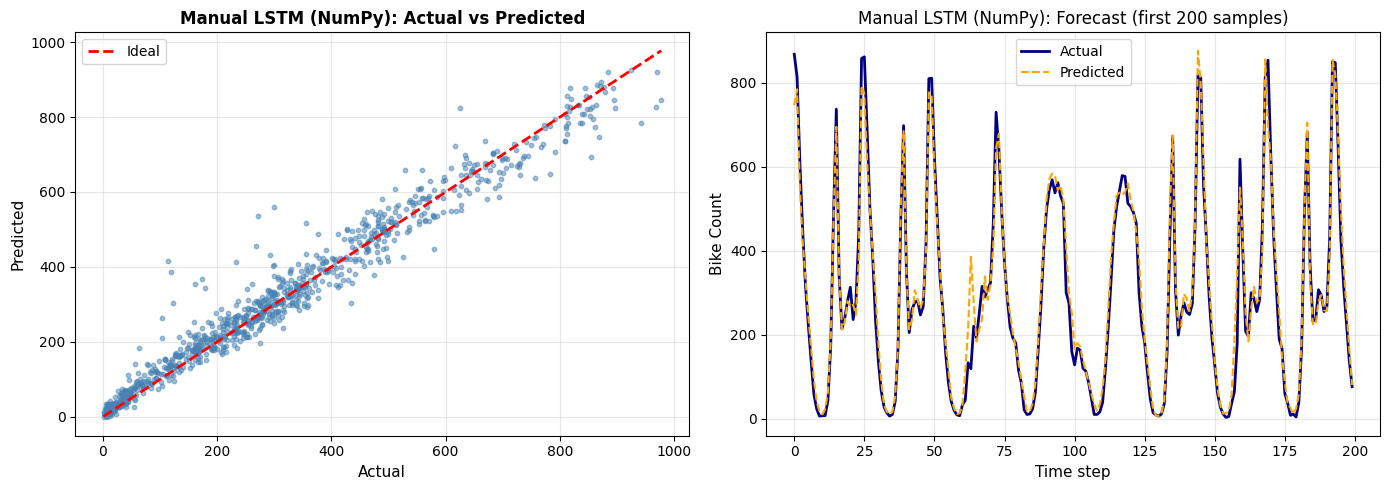

In [ ]:
# Прогнозы ручной модели
y_pred_test_manual = manual_lstm.predict(X_test).flatten()

# Обратное преобразование
y_test_inv_manual, y_pred_test_inv_manual = inverse_transform_target(
    y_test, y_pred_test_manual, scaler, target_idx, n_features
)

# Оценка и визуализация
metrics_manual = evaluate_and_plot(
    y_test, y_pred_test_manual,
    y_test_inv_manual, y_pred_test_inv_manual,
    model_name="Manual LSTM (NumPy)",
    history=None,
    sample_size=200
)

# GRU

## Ручная реализация

In [ ]:

class ManualGRU:
    def __init__(self, input_dim, hidden_dim=64, lr=0.001):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.t = 0

        # Инициализация весов
        sc = np.sqrt(1.0 / hidden_dim)

        self.W_z = np.random.randn(input_dim, hidden_dim) * sc
        self.U_z = np.random.randn(hidden_dim, hidden_dim) * sc
        self.b_z = np.zeros(hidden_dim)

        self.W_r = np.random.randn(input_dim, hidden_dim) * sc
        self.U_r = np.random.randn(hidden_dim, hidden_dim) * sc
        self.b_r = np.zeros(hidden_dim)

        self.W_h = np.random.randn(input_dim, hidden_dim) * sc
        self.U_h = np.random.randn(hidden_dim, hidden_dim) * sc
        self.b_h = np.zeros(hidden_dim)

        self.W_out = np.random.randn(hidden_dim, 1) * sc
        self.b_out = np.zeros(1)

        self._init_adam_moments()

    def _init_adam_moments(self):
        self.params = ['W_z', 'U_z', 'b_z', 'W_r', 'U_r', 'b_r',
                       'W_h', 'U_h', 'b_h', 'W_out', 'b_out']
        self.moments = {}
        for name in self.params:
            val = getattr(self, name)
            self.moments[f'm_{name}'] = np.zeros_like(val)
            self.moments[f'v_{name}'] = np.zeros_like(val)

    def _sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    def _tanh(self, x):
        return np.tanh(x)

    def forward(self, X):
        B, T, _ = X.shape

        h = np.zeros((B, self.hidden_dim))

        self._X = X
        self._hs = [h.copy()]
        self._zs, self._rs, self._hs_tilda = [], [], []

        for t in range(T):
            x_t = X[:, t, :]

            z = self._sigmoid(x_t @ self.W_z + h @ self.U_z + self.b_z)

            r = self._sigmoid(x_t @ self.W_r + h @ self.U_r + self.b_r)

            h_prev_reset = r * h
            h_tilda = self._tanh(x_t @ self.W_h + h_prev_reset @ self.U_h + self.b_h)

            h = (1 - z) * h + z * h_tilda

            self._hs.append(h.copy())
            self._zs.append(z)
            self._rs.append(r)
            self._hs_tilda.append(h_tilda)

        y_pred = h @ self.W_out + self.b_out
        return y_pred

    def backward(self, y_true, y_pred):
        B, T, _ = self._X.shape
        dy = 2 * (y_pred - y_true.reshape(-1, 1)) / B

        # Градиенты выходного слоя
        dW_out = self._hs[T].T @ dy
        db_out = np.sum(dy, axis=0)

        # Начальное состояние градиента для скрытого слоя
        dh_next = dy @ self.W_out.T

        # Накопление градиентов
        grads = {name: np.zeros_like(getattr(self, name)) for name in self.params}

        # BPTT loop
        for t in reversed(range(T)):
            x_t = self._X[:, t, :]
            h_prev = self._hs[t]

            z = self._zs[t]
            r = self._rs[t]
            h_tilda = self._hs_tilda[t]

            dh_tilda = dh_next * z
            dz = dh_next * (h_tilda - h_prev)

            dh_prev_direct = dh_next * (1 - z)

            dz_raw = dz * z * (1 - z)
            grads['W_z'] += x_t.T @ dz_raw
            grads['U_z'] += h_prev.T @ dz_raw
            grads['b_z'] += np.sum(dz_raw, axis=0)

            dh_tilda_raw = dh_tilda * (1 - h_tilda**2)
            grads['W_h'] += x_t.T @ dh_tilda_raw
            grads['b_h'] += np.sum(dh_tilda_raw, axis=0)

            dh_prev_reset = dh_tilda_raw @ self.U_h.T
            grads['U_h'] += (r * h_prev).T @ dh_tilda_raw

            dr = dh_prev_reset * h_prev
            dr_raw = dr * r * (1 - r)

            grads['W_r'] += x_t.T @ dr_raw
            grads['U_r'] += h_prev.T @ dr_raw
            grads['b_r'] += np.sum(dr_raw, axis=0)

            dh_next = (dh_prev_direct +
                       dz_raw @ self.U_z.T +
                       dr_raw @ self.U_r.T +
                       dh_prev_reset * r)

        # Обновление весов
        grads['W_out'] = dW_out
        grads['b_out'] = db_out
        for name in self.params:
            self._adam_update(name, grads[name])

    def _adam_update(self, name, grad):
        param = getattr(self, name)
        grad = np.asarray(grad).reshape(param.shape)

        beta1, beta2, eps = 0.9, 0.999, 1e-8

        m = self.moments[f'm_{name}']
        v = self.moments[f'v_{name}']

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        self.t += 1
        m_hat = m / (1 - beta1 ** self.t)
        v_hat = v / (1 - beta2 ** self.t)

        param -= self.lr * m_hat / (np.sqrt(v_hat) + eps)

        self.moments[f'm_{name}'] = m
        self.moments[f'v_{name}'] = v

    def fit(self, X, y, epochs=50, batch_size=32):
        print(" Обучение Manual GRU")
        n = X.shape[0]
        for epoch in range(epochs):
            idx = np.random.permutation(n)
            X_shuf, y_shuf = X[idx], y[idx]
            epoch_loss = 0
            n_batches = 0

            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                X_b, y_b = X_shuf[start:end], y_shuf[start:end]

                y_pred = self.forward(X_b)
                loss = np.mean((y_pred - y_b.reshape(-1, 1))**2)
                epoch_loss += loss
                n_batches += 1

                self.backward(y_b, y_pred)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/n_batches:.4f}")

    def predict(self, X):
        y_pred = self.forward(X)
        return y_pred.flatten()

## Сравнение

🛠️ Обучение Manual GRU (NumPy)...
Epoch 10/50 | Loss: 0.0013
Epoch 20/50 | Loss: 0.0011
Epoch 30/50 | Loss: 0.0010
Epoch 40/50 | Loss: 0.0009
Epoch 50/50 | Loss: 0.0008

==================== MANUAL GRU (NUMPY) ====================

=== МЕТРИКИ (обратное преобразование) ===
Метрика         Значение            
-----------------------------------
MAE             27.24               
RMSE            41.28               
R² Score        0.9650              

Корреляция Пирсона: 0.9826 (p=0.000000)


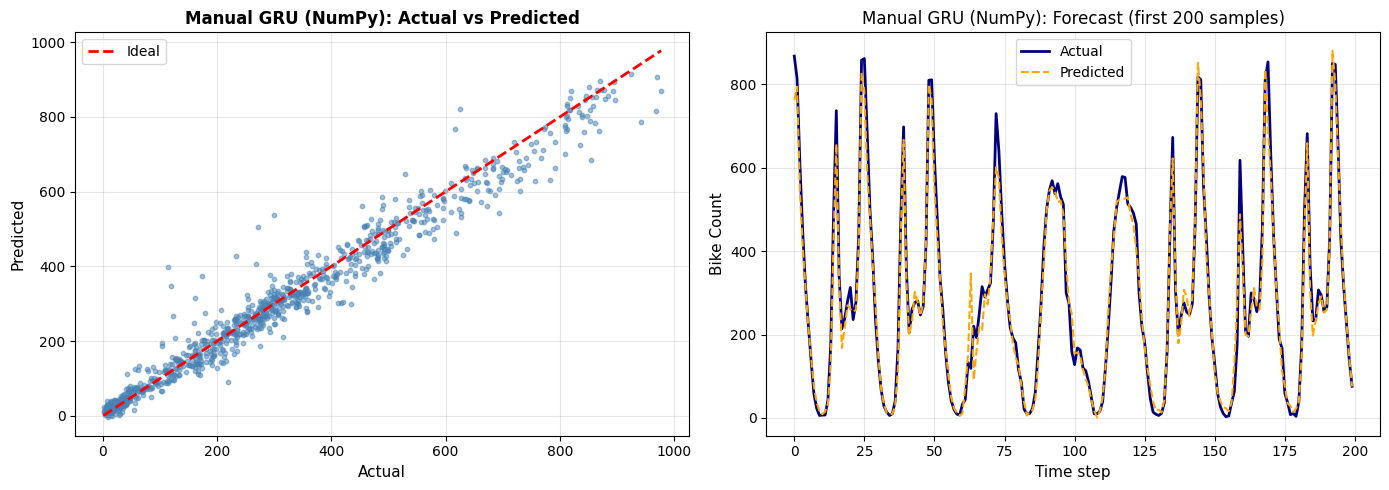

In [ ]:

# --- Обучение и оценка Manual GRU ---
manual_gru = ManualGRU(input_dim=X_train.shape[2], hidden_dim=64, lr=0.001)
manual_gru.fit(X_train, y_train, epochs=50, batch_size=32)

manual_gru_pred = manual_gru.predict(X_test)
y_test_inv_manual_gru, y_pred_test_inv_manual_gru = inverse_transform_target(
    y_test, manual_gru_pred, scaler, target_idx, n_features
)

metrics_manual_gru = evaluate_and_plot(
    y_test, manual_gru_pred,
    y_test_inv_manual_gru, y_pred_test_inv_manual_gru,
    model_name="Manual GRU (NumPy)",
    history=None,
    sample_size=200
)


In [ ]:

print(f"{'='*60}")
print(f"{'Метрика':<15} {'TF GRU':<20} {'Manual GRU':<20}")
print("-" * 60)
print(f"{'MAE':<15} {metrics_tf_gru['MAE']:<20.2f} {metrics_manual_gru['MAE']:<20.2f}")
print(f"{'RMSE':<15} {metrics_tf_gru['RMSE']:<20.2f} {metrics_manual_gru['RMSE']:<20.2f}")
print(f"{'R² Score':<15} {metrics_tf_gru['R2']:<20.4f} {metrics_manual_gru['R2']:<20.4f}")

Метрика         TF GRU               Manual GRU          
------------------------------------------------------------
MAE             29.56                27.24               
RMSE            45.06                41.28               
R² Score        0.9583               0.9650              
